In [ ]:
pip install pdfplumber python-docx scikit-learn nltk pandas

In [ ]:
import zipfile
zip_path = "/content/Resumes.zip"
extract_path = "/content/Resumes"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP extracted successfully")

ZIP extracted successfully


In [ ]:
import os
import pdfplumber
from docx import Document
import pandas as pd
import re
import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
import os
import pdfplumber
from docx import Document

folder_path = "/content/Resumes"

files = os.listdir(folder_path)

for file_name in files:
    file_path = os.path.join(folder_path, file_name)

    if file_name.lower().endswith(".pdf"):
        with pdfplumber.open(file_path) as pdf:
            text = ""
            for page in pdf.pages:
                text += page.extract_text() or ""

        print("\nReading:", file_name)
        print(text[:300])

In [ ]:
import os
import pdfplumber
from docx import Document
import pandas as pd

base_path = "/content/Resumes/Resumes"

resume_data = []

for category in os.listdir(base_path):
    category_path = os.path.join(base_path, category)

    if not os.path.isdir(category_path):
        continue

    for file_name in os.listdir(category_path):
        file_path = os.path.join(category_path, file_name)
        text = ""

        if file_name.lower().endswith(".pdf"):
            with pdfplumber.open(file_path) as pdf:
                for page in pdf.pages:
                    text += page.extract_text() or ""

        elif file_name.lower().endswith(".docx"):
            doc = Document(file_path)
            for para in doc.paragraphs:
                text += para.text + " "

        else:
            continue

        if text.strip():
            resume_data.append({
                "resume_text": text,
                "category": category
            })

df = pd.DataFrame(resume_data)
df.to_csv("/content/resume_dataset.csv", index=False)

print("CSV created successfully")
print("Total resumes:", len(df))

CSV created successfully
Total resumes: 53


In [ ]:
import os
import pdfplumber
from docx import Document
import pandas as pd

base_path =r"/content/Resumes/Resumes"

resume_data = []

# Loop through each category folder
for category in os.listdir(base_path):

    category_path = os.path.join(base_path, category)

    # Skip if not a folder
    if not os.path.isdir(category_path):
        continue

    # Loop through each resume in that folder
    for file_name in os.listdir(category_path):

        file_path = os.path.join(category_path, file_name)
        text = ""

        # PDF
        if file_name.lower().endswith(".pdf"):
            with pdfplumber.open(file_path) as pdf:
                page = pdf.pages[0]
                text = page.extract_text()

        # DOCX
        elif file_name.lower().endswith(".docx"):
            doc = Document(file_path)
            for para in doc.paragraphs:
                text += para.text

        # Skip DOC and others
        else:
            continue

        # Save only valid text
        if text:
            resume_data.append({
                "resume_text": text,
                "category": category
            })

# Convert to DataFrame
df = pd.DataFrame(resume_data)

print("Total resumes:", len(df))
print(df["category"].value_counts())
df.to_csv("resume_dataset.csv", index=False)
print("Final CSV created successfully")


Total resumes: 53
category
react developer                    19
workday resumes                    11
SQL Developer Lightning insight    11
Peoplesoft resumes                 10
Intrenship                          2
Name: count, dtype: int64
Final CSV created successfully


##EDA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
gg=pd.read_csv("/content/resume_dataset (1).csv")

In [ ]:
gg.head()

,resume_text,category
0,Having 4.6 years of experience in PeopleSoft ...,Peoplesoft resumes
1,Anubhav Kumar Singh\t\t To work in a glob...,Peoplesoft resumes
2,C O N T A C T : Address: ...,Peoplesoft resumes
3,Tanna Sujatha OBJECTIVE Seeking a challeng...,Peoplesoft resumes
4,PeopleSoft Administration Vivekanand Sayana ...,Peoplesoft resumes


In [ ]:
gg.shape

(53, 2)

In [ ]:
gg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   resume_text  53 non-null     object
 1   category     53 non-null     object
dtypes: object(2)
memory usage: 980.0+ bytes


In [ ]:
gg.isnull().sum()

,0
resume_text,0
category,0


In [ ]:
gg["category"].value_counts()


,count
category,
react developer,19
SQL Developer Lightning insight,11
workday resumes,11
Peoplesoft resumes,10
Intrenship,2


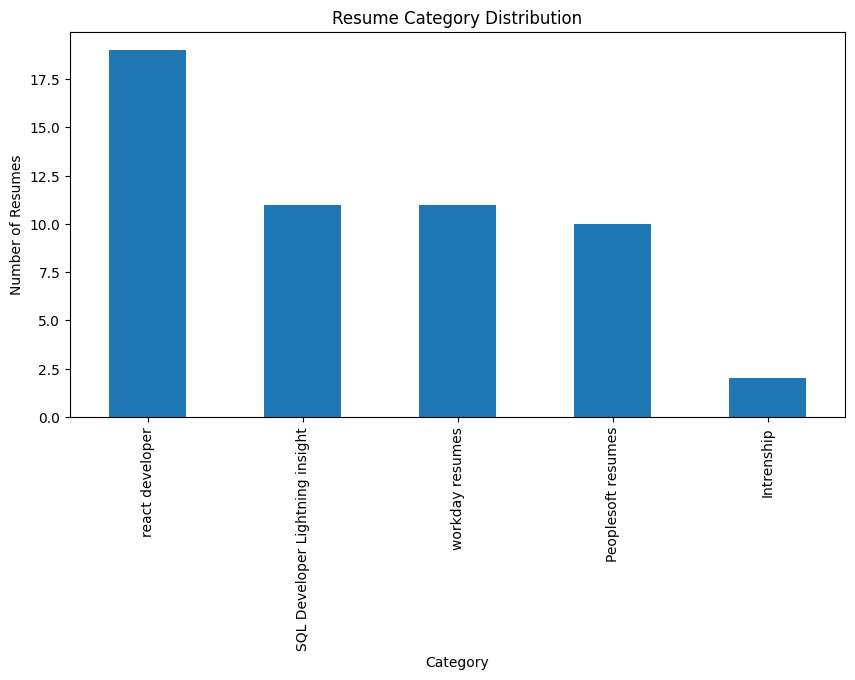

In [ ]:
import matplotlib.pyplot as plt

gg["category"].value_counts().plot(kind="bar", figsize=(10,5))
plt.title("Resume Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Resumes")
plt.show()


In [ ]:
gg["text_length"] = gg["resume_text"].apply(len)

gg["text_length"].describe()


,text_length
count,53.000000
mean,4011.754717
std,2382.449958
min,995.000000
25%,2618.000000
50%,3634.000000
75%,5090.000000
max,15340.000000


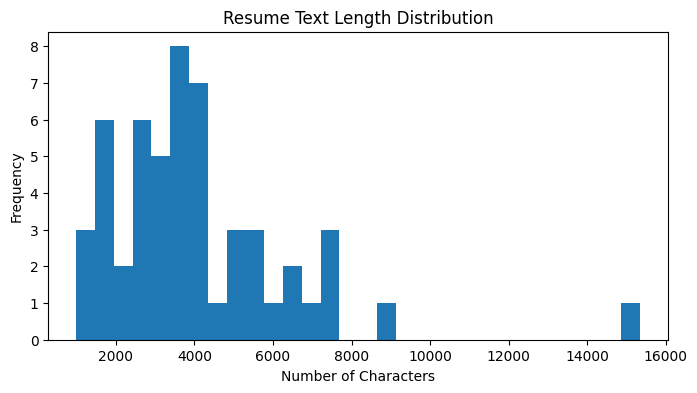

In [ ]:
#this chart represent resum text length or number of charecters

gg["text_length"].plot(kind="hist", bins=30, figsize=(8,4))
plt.title("Resume Text Length Distribution")
plt.xlabel("Number of Characters")
plt.show()


In [ ]:
#It extracts the 300 charecters of each categorey of resume

for cat in gg["category"].unique():
    print("\nCategory:", cat)
    print(gg[gg["category"] == cat]["resume_text"].iloc[0][:300])



Category: Peoplesoft resumes
 Having 4.6 years of experience in PeopleSoft application enhancement, Support and Upgrade projects. Well experienced on People tools and having Functional knowledge HCM and FSCM Applications.    Master of computer applications, Vinayaka Missions University, Chennai, Tamilnadu, India (3year program-

Category: Intrenship
Name: Ravali P                                                                                Curriculum Vitae                                            Specialization: BE (computer science and Engg)       To utilize my technical skills for achieving the target and developing the best performance i

Category: workday resumes
                                                                           Vinay kumar .v
Workday Functional Consultant  EXPERTISE SUMMARY	 Having 4.2 years of Total Experience in as a Workday  Functional Consultant. Knowledge on the functional modules of Workday (Core HCM, Supervisory Organization,

Category: react d

##Text Cleaning

In [ ]:
#in that we cleaned the text by removing spaces and special charecters
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = ' '.join(word for word in text.split() if word not in stop_words)
    return text

gg["clean_text"] = gg["resume_text"].apply(clean_text)

gg[["resume_text", "clean_text"]].head()



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,resume_text,clean_text
0,Having 4.6 years of experience in PeopleSoft ...,years experience peoplesoft application enhanc...
1,Anubhav Kumar Singh\t\t To work in a glob...,anubhav kumar singh work globally competitive ...
2,C O N T A C T : Address: ...,c n c address manyata tech park nagavara banga...
3,Tanna Sujatha OBJECTIVE Seeking a challeng...,tanna sujatha objective seeking challenging ro...
4,PeopleSoft Administration Vivekanand Sayana ...,peoplesoft administration vivekanand sayana ca...


##Feature Extraction (TF-IDF)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(gg["clean_text"])
y = gg["category"]


##Train–Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


##Model  (Naive Bayes)

In [ ]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)


MultinomialNB()

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.8181818181818182
                                 precision    recall  f1-score   support

             Peoplesoft resumes       1.00      0.50      0.67         2
SQL Developer Lightning insight       1.00      0.67      0.80         3
                react developer       0.50      1.00      0.67         2
                workday resumes       1.00      1.00      1.00         4

                       accuracy                           0.82        11
                      macro avg       0.88      0.79      0.78        11
                   weighted avg       0.91      0.82      0.82        11



##Model Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))


Logistic Regression Accuracy: 0.8181818181818182
                                 precision    recall  f1-score   support

             Peoplesoft resumes       1.00      0.50      0.67         2
SQL Developer Lightning insight       1.00      0.67      0.80         3
                react developer       0.50      1.00      0.67         2
                workday resumes       1.00      1.00      1.00         4

                       accuracy                           0.82        11
                      macro avg       0.88      0.79      0.78        11
                   weighted avg       0.91      0.82      0.82        11



##Model Support Vector Machine (Linear SVM)

In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


SVM Accuracy: 0.8181818181818182
                                 precision    recall  f1-score   support

             Peoplesoft resumes       1.00      0.50      0.67         2
SQL Developer Lightning insight       1.00      0.67      0.80         3
                react developer       0.50      1.00      0.67         2
                workday resumes       1.00      1.00      1.00         4

                       accuracy                           0.82        11
                      macro avg       0.88      0.79      0.78        11
                   weighted avg       0.91      0.82      0.82        11



##Model Random Forest (Optional / Comparison)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.9090909090909091
                                 precision    recall  f1-score   support

             Peoplesoft resumes       1.00      1.00      1.00         2
SQL Developer Lightning insight       1.00      0.67      0.80         3
                react developer       0.67      1.00      0.80         2
                workday resumes       1.00      1.00      1.00         4

                       accuracy                           0.91        11
                      macro avg       0.92      0.92      0.90        11
                   weighted avg       0.94      0.91      0.91        11



In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc


In [ ]:
for model, acc in results.items():
    print(f"{model}: {acc:.4f}")


Naive Bayes: 0.8182
Logistic Regression: 0.8182
Linear SVM: 0.8182
Random Forest: 0.9091


In [ ]:
best_model = max(results, key=results.get)
best_accuracy = results[best_model]

print("Best Model:", best_model)
print("Best Accuracy:", best_accuracy)


Best Model: Random Forest
Best Accuracy: 0.9090909090909091


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# TF-IDF
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(gg["clean_text"])
y = gg["category"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Random Forest (BEST MODEL)
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully")


Random Forest model trained successfully


In [ ]:
print(type(rf_model))
print(type(tfidf))


<class 'sklearn.ensemble._forest.RandomForestClassifier'>
<class 'sklearn.feature_extraction.text.TfidfVectorizer'>


In [ ]:
import joblib

joblib.dump(rf_model, "resume_rf_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully")


Model and vectorizer saved successfully
